In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import gaussian_kde
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
#df = dd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N.csv', \
#                 names=['objid','ra','dec','tilenum','nuv_flux','nuv_fluxerr', \
#                         'fuv_flux','fuv_fluxerr','nuv_poserr'],header=0)
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat50_00N__55_00N_lite.csv')
#df = pd.read_csv(roots_tfm + '/Galex/GUVCat_AIS_FOV055_glat05_00N__10_00N_lite.csv')
df = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_best.csv')
df_all = pd.read_csv(roots_tfm + '/Galex/match_Galex_UVOT_OM_all.csv')

In [3]:
df.head()

,objid,ra_1,dec_1,fuv_flux,fuv_fluxerr,nuv_flux,nuv_fluxerr,nuv_poserr,SRCNUM_CUV,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR,COUNT,angDist
0,6373097221993268460,83.884105,40.187670,27.279566,3.999979,29.566187,4.045698,0.625514,67130,0,1014525,83.883805,40.187728,0.358525,3,0.852187
1,6371795405592593744,330.548352,66.793384,-999.000000,-999.000000,10.336556,2.764180,1.608465,259861,0,5880541,330.547788,66.793715,0.184504,3,1.434355
2,6373976851694487732,100.268286,26.473098,-999.000000,-999.000000,3.807085,1.412635,1.266602,78042,0,1320921,100.267939,26.473093,0.611849,1,1.119616
3,6373976851696585056,100.261757,26.502480,3.971011,1.676836,6.980900,1.855379,1.075492,78038,0,1320711,100.262181,26.502354,0.489386,4,1.438630
4,6373976851696586502,100.349042,26.694327,10.779969,3.866972,25.672947,4.400514,1.088975,78117,0,1323941,100.349435,26.693479,0.391472,6,3.304391


In [4]:
df=df.replace(-999,np.nan)

In [5]:
df.shape

(242048, 16)

In [6]:
df_all.shape

(260448, 16)

In [7]:
df_merge = df_all[df_all.duplicated(subset=['objid'])].merge(df,on='objid')
df['SUSPICIOUS_MATCH'] = False
df.loc[df['objid'].isin(df_merge['objid']),'SUSPICIOUS_MATCH'] = True

In [8]:
df.dtypes

objid                 int64
ra_1                float64
dec_1               float64
fuv_flux            float64
fuv_fluxerr         float64
nuv_flux            float64
nuv_fluxerr         float64
nuv_poserr          float64
SRCNUM_CUV            int64
SRCNUM_OM             int64
SRCNUM_UVOT           int64
RA_2                float64
DEC_2               float64
POSERR              float64
COUNT                 int64
angDist             float64
SUSPICIOUS_MATCH       bool
dtype: object

In [9]:
df = df.rename(columns={'ra_1':'RA','dec_1':'DEC','nuv_poserr':'POSERR','objid':'SRCNUM',\
                       'nuv_flux':'NUV_FLUX', 'nuv_fluxerr' : 'NUV_FLUX_ERR', \
                         'fuv_flux': 'FUV_FLUX','fuv_fluxerr' : 'FUV_FLUX_ERR'})

In [10]:
df.head()

,SRCNUM,RA,DEC,FUV_FLUX,FUV_FLUX_ERR,NUV_FLUX,NUV_FLUX_ERR,POSERR,SRCNUM_CUV,SRCNUM_OM,SRCNUM_UVOT,RA_2,DEC_2,POSERR,COUNT,angDist,SUSPICIOUS_MATCH
0,6373097221993268460,83.884105,40.187670,27.279566,3.999979,29.566187,4.045698,0.625514,67130,0,1014525,83.883805,40.187728,0.358525,3,0.852187,False
1,6371795405592593744,330.548352,66.793384,NaN,NaN,10.336556,2.764180,1.608465,259861,0,5880541,330.547788,66.793715,0.184504,3,1.434355,False
2,6373976851694487732,100.268286,26.473098,NaN,NaN,3.807085,1.412635,1.266602,78042,0,1320921,100.267939,26.473093,0.611849,1,1.119616,False
3,6373976851696585056,100.261757,26.502480,3.971011,1.676836,6.980900,1.855379,1.075492,78038,0,1320711,100.262181,26.502354,0.489386,4,1.438630,False
4,6373976851696586502,100.349042,26.694327,10.779969,3.866972,25.672947,4.400514,1.088975,78117,0,1323941,100.349435,26.693479,0.391472,6,3.304391,False


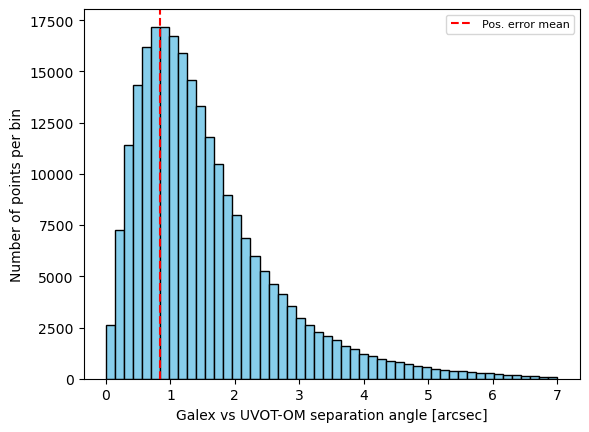

In [11]:
# Plot figure
fig, ax =plt.subplots()
(n,bins,patches) = ax.hist(df[df['angDist']<7]['angDist'], bins=50, color='skyblue',edgecolor='black')
ax.axvline(np.mean(df['POSERR']), linestyle='dashed', color='r',label='Pos. error mean')
ax.set_xlabel("Galex vs UVOT-OM separation angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/Galex/match_Galex_UVOT_OM.png',dpi=1200)  

In [12]:
filepath_count = roots_tfm + '/Galex/count_random_match.txt'
df_count = pd.read_csv(filepath_count,sep=' ',skiprows=[0],header=None,usecols=[5])
sum = 0
i=0
while sum<(df.shape[0] - df_count[5].sum()):
    sum = sum + n[i]
    i=i+1
print("Sum of cumulated matchs until bin number " + str(i) + " : " + str(sum))
print("Corresponding maximum angle : {:.2E}".format(bins[i]))

Sum of cumulated matchs until bin number 45 : 241066.0
Corresponding maximum angle : 6.30E+00


In [13]:
df = df[df['angDist']<4]
df.shape

(231963, 17)

In [14]:
df = df.astype({'SRCNUM': np.int64, 'NUV_FLUX': np.float32, 'FUV_FLUX': np.float32, \
                'NUV_FLUX_ERR': np.float32, 'FUV_FLUX_ERR': np.float32, 'RA': np.float64, \
                'DEC': np.float64, 'POSERR': np.float32})

In [15]:
df_radec = df[['RA','DEC','POSERR','SRCNUM']]
df_radec.shape

(231963, 5)

In [16]:
df_entries = df[['SRCNUM','NUV_FLUX','NUV_FLUX_ERR','FUV_FLUX','FUV_FLUX_ERR','SRCNUM_OM','SRCNUM_CUV']]
df_entries =df_entries.rename(columns={'SRCNUM': 'SRCNUM_GALEX'})
df_entries_cor = df_entries[['SRCNUM_CUV','SRCNUM_GALEX','SRCNUM_OM']].copy()
df_entries_cor['NUV_UVW2_FLUX'] = np.nan
df_entries_cor['NUV_UVW2_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVW2_FLUX'] = np.nan
df_entries_cor['FUV_UVW2_FLUX_ERR'] = np.nan
df_entries_cor['NUV_UVM2_FLUX'] = np.nan
df_entries_cor['NUV_UVM2_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVM2_FLUX'] = np.nan
df_entries_cor['FUV_UVM2_FLUX_ERR'] = np.nan
df_entries_cor['NUV_UVW1_FLUX'] = np.nan
df_entries_cor['NUV_UVW1_FLUX_ERR'] = np.nan
df_entries_cor['FUV_UVW1_FLUX'] = np.nan
df_entries_cor['FUV_UVW1_FLUX_ERR'] = np.nan

In [17]:
dat_OM=pd.read_csv(roots_tfm + '/XMM-Newton/Entries_OM_galaxies.csv')

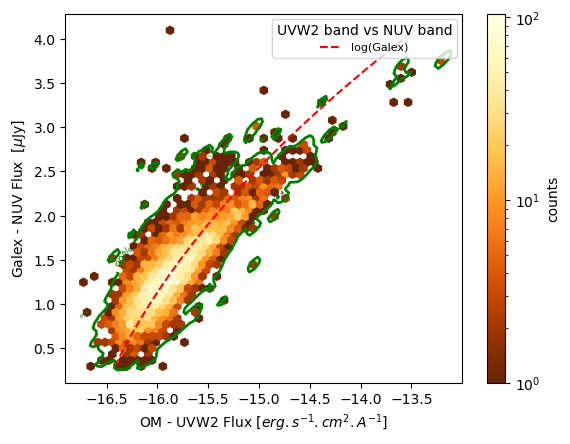

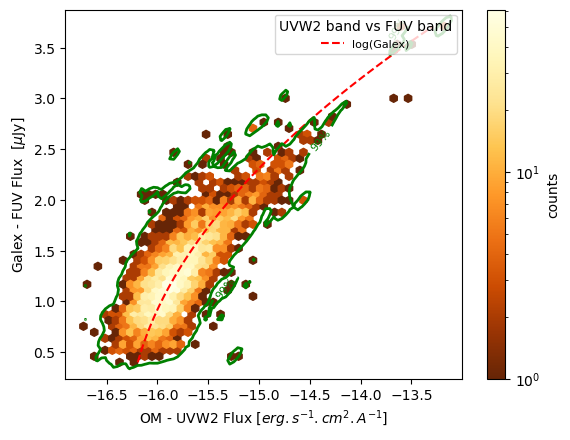

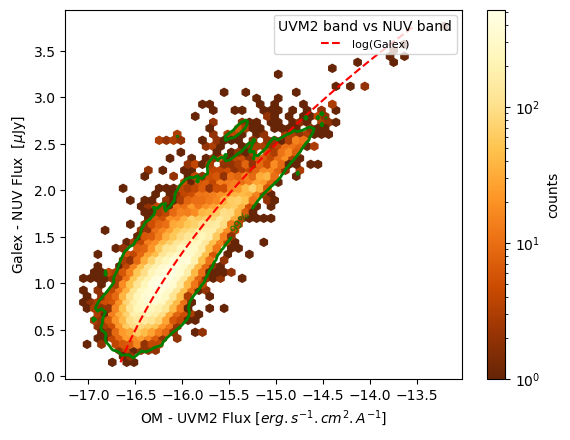

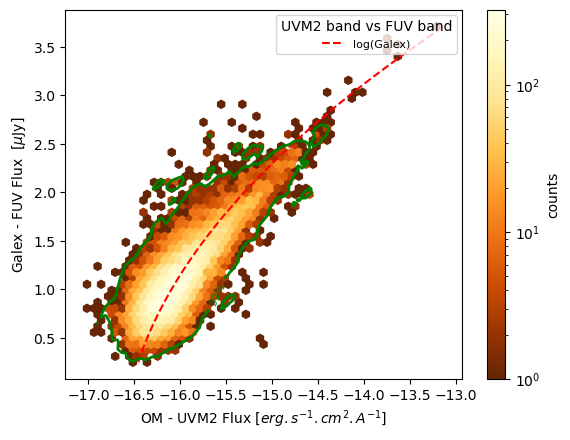

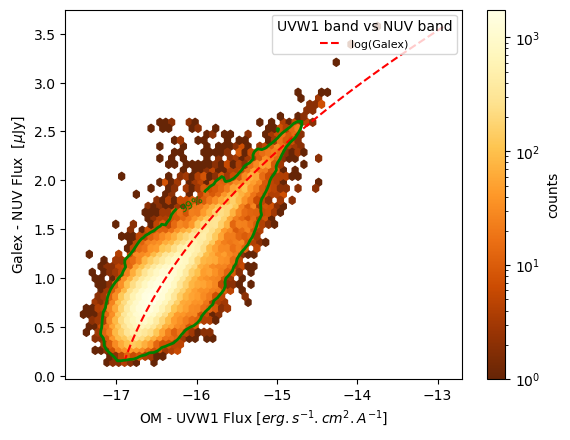

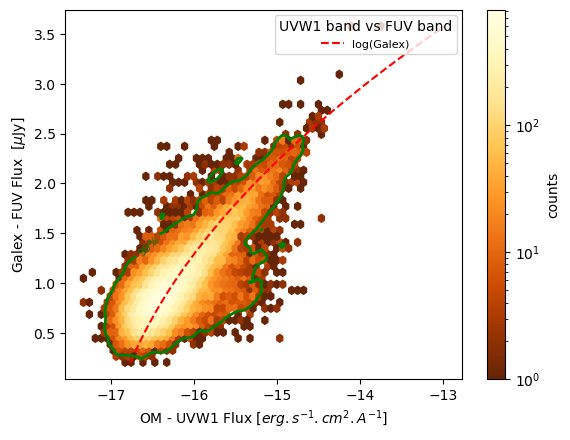

In [18]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_FLUX'
        flux_galex_err = flux_galex + '_FLUX_ERR'

         # Data frame Galex for this band
        df_flux_galex = df_entries[[flux_galex_name,flux_galex_err,'SRCNUM_OM']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_OM'] != 0]
        df_flux_galex=df_flux_galex.reset_index()

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_om, left_on='SRCNUM_OM', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=np.log10(df_merge[flux_galex_name])
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        
        x=np.log10(df_merge.loc[:,flux_name])
        y=np.log10(df_merge.loc[:,flux_galex_name]) 
        p = np.poly1d(np.polyfit(y,x, deg=2))
        yp = np.linspace(y.min(), y.max(), 100)
        ax.plot(p(yp), yp, color='r', linestyle='dashed', label= "log(Galex)")   

        xmin, xmax= ax.get_xlim()
        ymin, ymax= ax.get_ylim()
        
        random_row_index = np.random.default_rng().choice(df_merge.index.values,100000)
        data = np.vstack([np.log10(df_merge.loc[random_row_index,flux_name]),np.log10(df_merge.loc[random_row_index,flux_galex_name])])
        kde = gaussian_kde(data)
        grid_x, grid_y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
        z = kde(grid_coords).reshape(100, 100)
        thresholds=np.percentile(kde.evaluate(kde.resample(40000)),1)
        contour = ax.contour(grid_x,grid_y,z,levels=[thresholds],colors='green',linewidths=2)
        ax.clabel(contour, inline=True, fontsize=8, fmt={thresholds: f"{99}%"})

        df_entries_cor.loc[:,flux_galex + '_' + flux_name] = 10**p(np.log10(df_entries.loc[:,flux_galex_name]))
        df_entries_cor.loc[:,flux_galex + '_' + flux_err] = 10**p(np.log10(df_entries.loc[:,flux_galex_err]))
        
        ax.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
        ax.set_ylabel("Galex - " + flux_galex + ' Flux  [' + "$\mu$" +"Jy]")
        ax.legend(loc='upper right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")
        fig.savefig(roots_tfm + '/Calibration/OM_' + flux + '_vs_Galex_ ' + flux_galex + "_galaxies.png",dpi=1200)  

In [19]:
df_merge.head()

,index_x,FUV_FLUX,FUV_FLUX_ERR,SRCNUM_OM,index_y,SRCNUM,UVW1_FLUX,UVW1_FLUX_ERR,UVW1_EXTENDED,UVW1_QUALITY_FLAG
0,39,13.727663,5.544144,2843657,185261,2843657,2.088716e-16,1.445731e-17,False,0
1,157,12.341626,3.522213,2279301,135187,2279301,6.364551e-17,7.554140e-18,False,0
2,190,153.614853,15.177100,5532752,377081,5532752,8.286474e-16,1.446986e-17,True,0
3,192,24.444431,5.550780,5527551,377039,5527551,2.258346e-16,8.739834e-18,True,0
4,282,32.266911,6.376765,3102952,217391,3102952,1.310206e-16,5.548749e-18,True,0


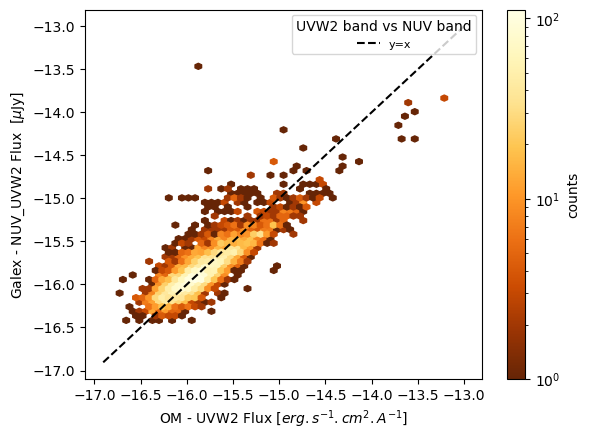

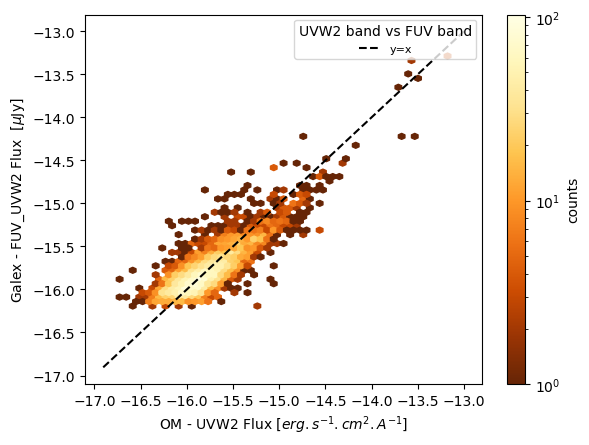

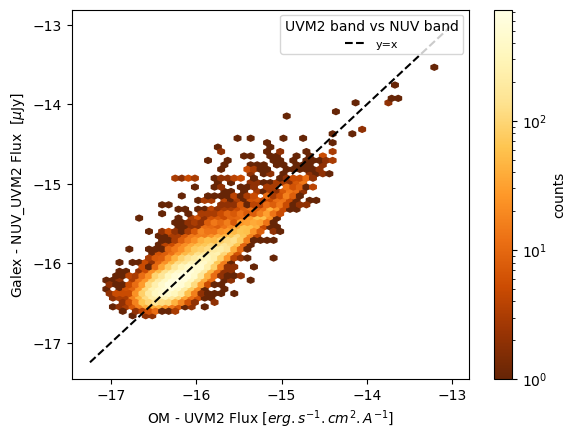

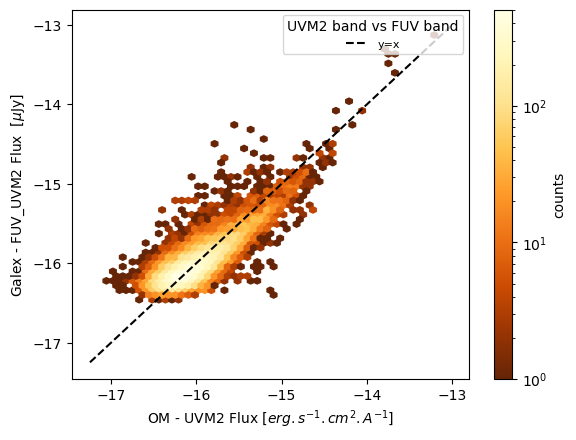

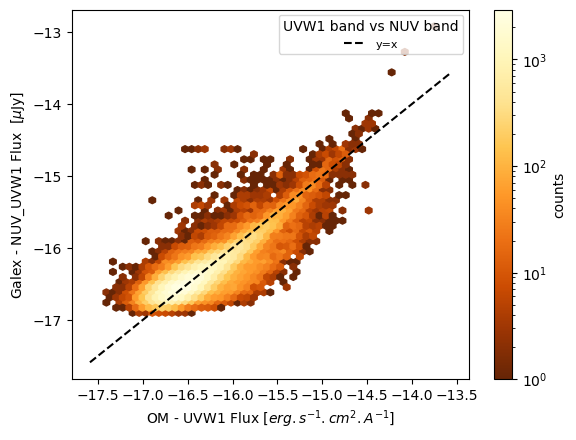

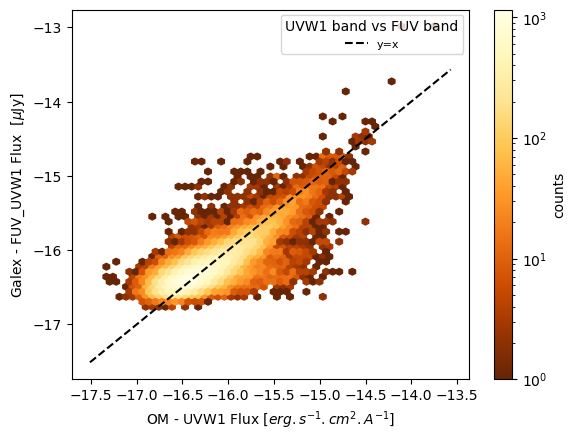

In [20]:
for flux in ['UVW2','UVM2','UVW1']: 
  
    flux_name = flux + '_FLUX'
    flux_err = flux + '_FLUX_ERR'
    flag_extended = flux + '_EXTENDED'
    flux_quality = flux + '_QUALITY_FLAG'

    # Dataframe OM for this band
    df_flux_om = dat_OM[['SRCNUM',flux_name,flux_err,flag_extended, flux_quality]].dropna(subset=[flux_name]).reset_index()  
    df_flux_om = df_flux_om[df_flux_om[flux_quality] == 0]

    for flux_galex in ['NUV','FUV']:
        
        flux_galex_name = flux_galex + '_' + flux + '_FLUX'
        flux_galex_err = flux_galex + '_' + flux_err

         # Data frame Galex for this band
        df_flux_galex = df_entries_cor[[flux_galex_name,flux_galex_err,'SRCNUM_OM']].dropna(subset=[flux_galex_name])
        df_flux_galex = df_flux_galex[df_flux_galex['SRCNUM_OM'] != 0]
        df_flux_galex=df_flux_galex.reset_index()

        # Merge with UVOT results
        df_merge = df_flux_galex.merge(df_flux_om, left_on='SRCNUM_OM', right_on='SRCNUM')

        # Plot figure
        fig, ax =plt.subplots()
        x=np.log10(df_merge[flux_name])
        y=np.log10(df_merge[flux_galex_name])
        hb =ax.hexbin(x,y,gridsize=50, bins='log', cmap='YlOrBr_r')
        cb = fig.colorbar(hb, ax=ax, label='counts')
        xmin, xmax= ax.get_xlim()
        ax.plot([xmin, xmax],[xmin, xmax], color='black', linestyle='dashed', label="y=x")         
        ax.set_xlabel("OM - " + flux + ' Flux [' + "$erg.s^{-1}.cm^{2}.A^{-1}]$")
        ax.set_ylabel("Galex - " + flux_galex + '_' + flux + ' Flux  [' + "$\mu$" +"Jy]")
        ax.legend(loc='upper right',prop={'size': 8},title= flux + " band vs " + flux_galex + " band")
        fig.savefig(roots_tfm + '/Calibration/OM_' + flux + '_vs_Galex_ ' + flux_galex + "_galaxies_post_calib.png",dpi=1200) 

In [21]:
df_entries_cor = df_entries_cor.drop({'SRCNUM_OM'},axis=1)

In [22]:
df_entries_cor.head()

,SRCNUM_CUV,SRCNUM_GALEX,NUV_UVW2_FLUX,NUV_UVW2_FLUX_ERR,FUV_UVW2_FLUX,FUV_UVW2_FLUX_ERR,NUV_UVM2_FLUX,NUV_UVM2_FLUX_ERR,FUV_UVM2_FLUX,FUV_UVM2_FLUX_ERR,NUV_UVW1_FLUX,NUV_UVW1_FLUX_ERR,FUV_UVW1_FLUX,FUV_UVW1_FLUX_ERR
0,67130,6373097221993268460,1.610557e-16,5.283320e-17,1.951783e-16,7.438713e-17,1.271664e-16,3.597090e-17,1.604253e-16,4.864434e-17,1.087118e-16,2.192958e-17,1.366816e-16,2.928160e-17
1,259861,6371795405592593744,8.585644e-17,4.427535e-17,NaN,NaN,6.183343e-17,2.967049e-17,NaN,NaN,4.253552e-17,1.756568e-17,NaN,NaN
2,78042,6373976851694487732,5.132335e-17,3.337335e-17,NaN,NaN,3.484527e-17,2.196306e-17,NaN,NaN,2.112800e-17,1.269454e-17,NaN,NaN
3,78038,6373976851696585056,6.946290e-17,3.726800e-17,7.419761e-17,5.815206e-17,4.871919e-17,2.467005e-17,4.847729e-17,3.414883e-17,3.159611e-17,1.433748e-17,2.914367e-17,1.766589e-17
4,78117,6373976851696586502,1.472314e-16,5.502192e-17,1.138708e-16,7.351462e-17,1.146188e-16,3.761271e-17,8.392551e-17,4.787526e-17,9.468738e-17,2.311485e-17,6.031306e-17,2.864737e-17


In [23]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
df_entries_cor.to_sql("Entries_GALEX", db_path, if_exists='replace', index=False, chunksize=1000, method="multi")

231963

In [24]:
df_entries_cor.to_csv(roots_tfm+'/Galex/Entries_Galex_Galaxies.csv',index=False)